# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../Data/yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


**Висновок:**
- В наборі даних 10886 рядків та 19 колонок.
- В одному рядку даних містяться дані за 1 год.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


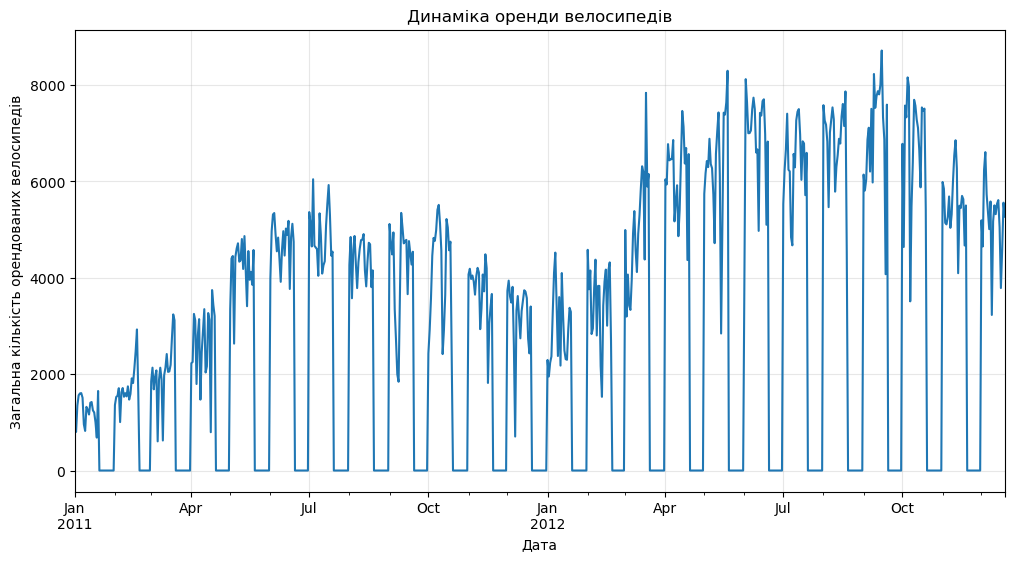

In [4]:
daily_data = df['count'].resample('D').sum()

daily_data.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Загальна кількість орендованих велосипедів'
)

plt.grid(True, alpha=0.3);

**Відповіді на питання (початок)**:

1. Графік має "заломи", тому що побудований по днях, а дані з 20-го числа (включно) кожного місяця й по 1-ше (не включно) наступного відсутні в наборі даних. Саме тому було прийнято рішення побудувати додатковий графік з наявних даних з метою надання коректних відповідей на наступні питання до даного завдання. Варто також зауважити, що щоденні значення загальної кількості орендованих велосипедів здатні коливатися через погодні умови (ясно, туман, легкий чи сильний дощ), день тижня (робочий, вихідний, святковий) та інш., наприклад, людський фактор.

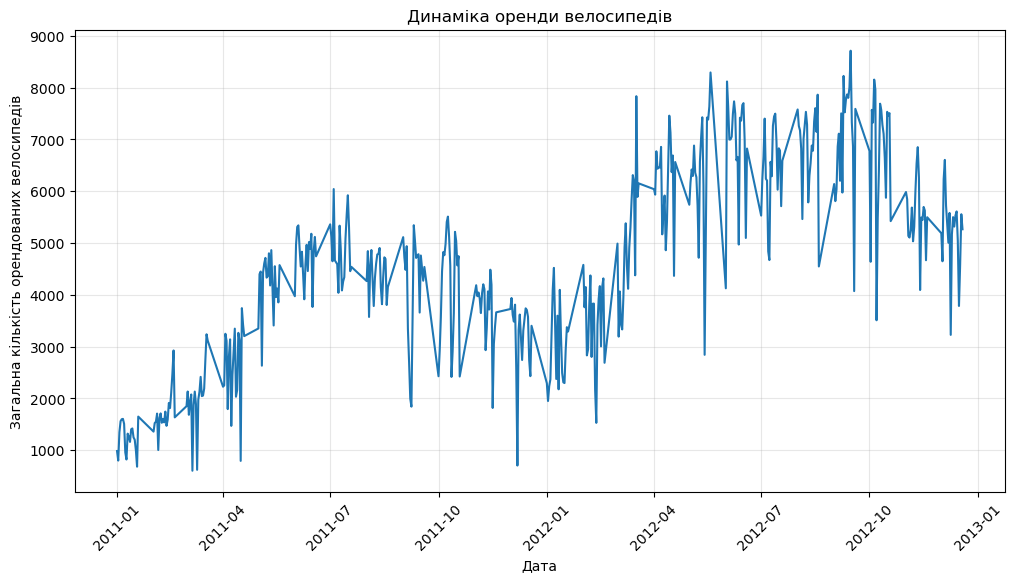

In [5]:
daily_data = df.groupby('date')['count'].sum()

daily_data.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Загальна кількість орендованих велосипедів'
)

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45);

**Відповіді на питання (продовження)**:

2. На графіку чітко спостерігається тенденція збільшення загальної кількості орендованих велосипедів у 2012 році у порівнянні з 2011 роком, що може свідчити про зростання популярності сервісу.
3. Сезонні коливання повторюються у 2011 і 2012 роках, а отже, вони стабільні: `Winter` — мінімум оренд, `Summer` — поступове зростання, `Monsoon` — максимум, `Post-Monsoon` — поступове падіння.
4. Аномально високі значення у 2011 році спостерігаються в липні, у той час як у 2012 році — у вересні, але обидва піки припадають на період `Monsoon`, що може свідчити про ідеальну погоду в сезон дощів, що й спровокувало такий попит на оренду велосипедів задля довгоочікуваного відпочинку на вулиці. Також прослідковується тенденція низької оренди велосипедів на початку року, що припадає на січень (`Winter`).


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [6]:
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

In [7]:
df['weather_season_india'] = df['month'].apply(get_season)

In [8]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_season_india
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,Winter
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,Winter
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,Winter
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,Winter
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,Winter


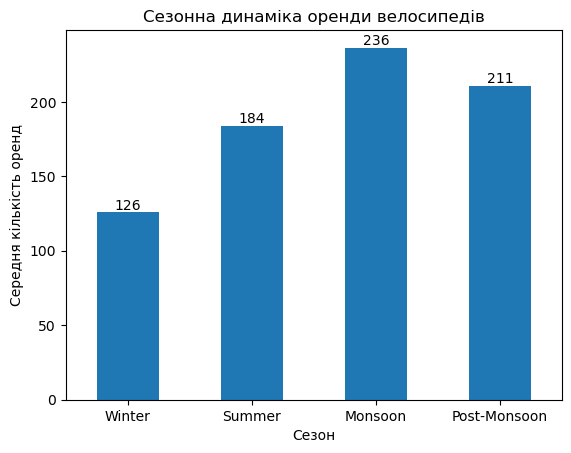

In [9]:
season_order = ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon']
df['weather_season_india'] = pd.Categorical(df['weather_season_india'], categories=season_order, ordered=True)
season_avg = df.groupby('weather_season_india', observed=True)['count'].mean()

ax = season_avg.plot.bar(
    title='Сезонна динаміка оренди велосипедів',
    xlabel='Сезон',
    ylabel='Середня кількість оренд'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%1.0f')

plt.xticks(rotation=0);

**Відповіді на питання**:

1. Найбільша середня кількість оренди велосипедів припадає на період `Monsoon`.
2. Така закономірність може свідчити про помірність температури після сильної літньої спеки та відсутність щоденних та інтенсивних дощів в регіоні, що характерно для даного сезону.
3. Оренда між найпопулярнішим та найменш популярним кварталом відрізняється майже в 2 рази.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


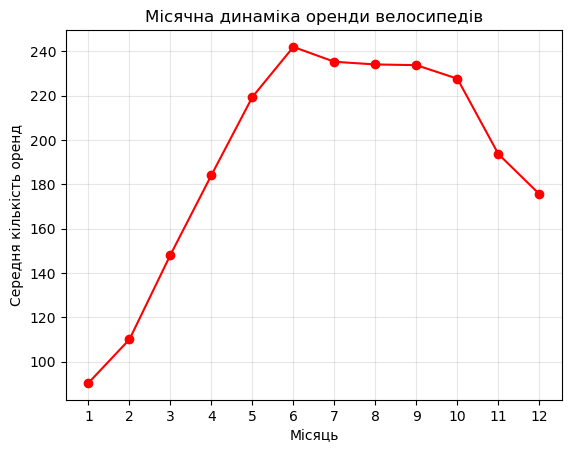

In [10]:
monthly_avg = df.groupby('month')['count'].mean()

monthly_avg.plot(
    color='red',
    marker='o',
    title='Місячна динаміка оренди велосипедів',
    xlabel='Місяць',
    ylabel='Середня кількість оренд'
)

plt.grid(True, alpha=0.3)
plt.xticks(range(1, 13));

**Відповіді на питання**:

1. Пік оренди спостерігається у червні, проте високі її показники продовжують ще тривати протягом липня — вересня. Чіткий спад оренди починає прослідковуватися з жовтня по січень, де і досягає свого мінімального значення.
2. Дана закономірність збігається з результатами з попереднього завдання: період `Monsoon` (6–9 місяців) — найактивніший (в середньому 236 оренд), у той час як `Winter` (12–2) — найменш активний (126 оренд).
3. Клімат безпосередньо впливає на попит на оренду протягом року: тепло, сухо — більше людей користуються велосипедами, у той час як коли жарко/холодно, мокро — менше.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

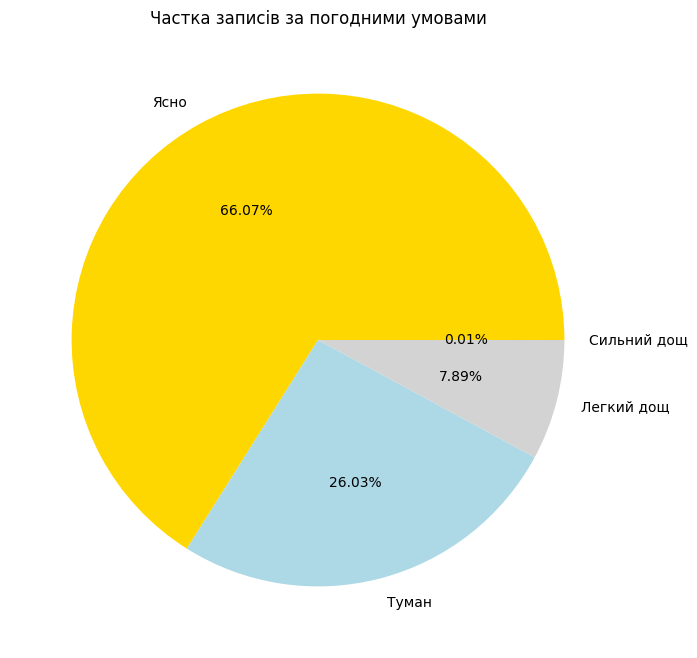

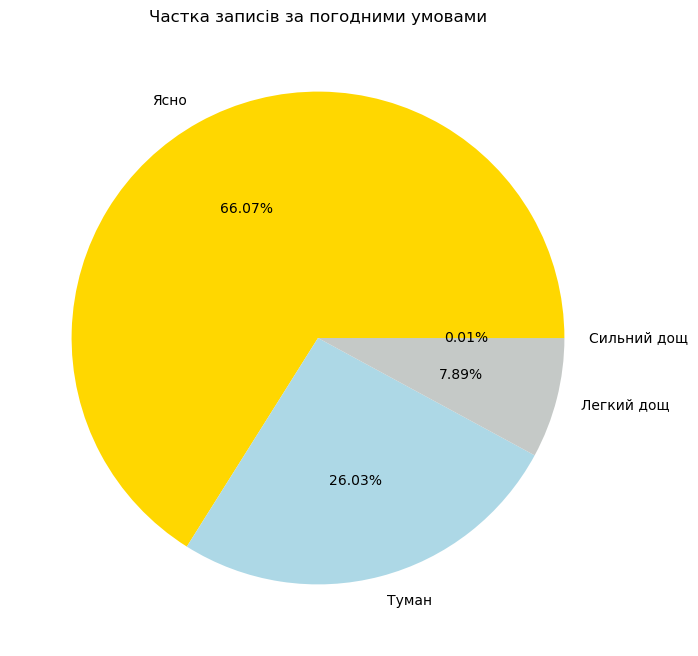

In [11]:
weather_chart = df.groupby('weather')['count'].count()
colors = ['#FFD700', '#ADD8E6', '#C5C9C7', '#9ACD32']

weather_chart.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=colors
);

**Відповіді на питання**:

1. В датасеті переважає ясна погода — близько 66 % від усіх записів.
2. Дні із сильним дощем є, але їх частка майже відсутня (0,01 %).
3. Погодні умови напряму впливають на попит на оренду велосипедів. Дивлячись на діаграму, можна стверджувати, що комфортні умови (в даному випадку ясна погода) формують основний обсяг оренди.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [12]:
def weather_condition(value):
    if value == 1:
        return 'Ясно'
    elif value == 2:
        return 'Туман'
    elif value == 3:
        return 'Легкий дощ'
    else:
        return 'Сильний дощ'

In [13]:
df['weather_condition'] = df['weather'].apply(weather_condition)

In [14]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,...,date,day,week,weekday_num,weekday,year,month,hour,weather_season_india,weather_condition
datetime,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,...,2011-01-01,1,52,5,Saturday,2011,1,0,Winter,Ясно
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,...,2011-01-01,1,52,5,Saturday,2011,1,1,Winter,Ясно
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,...,2011-01-01,1,52,5,Saturday,2011,1,2,Winter,Ясно
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,...,2011-01-01,1,52,5,Saturday,2011,1,3,Winter,Ясно
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,...,2011-01-01,1,52,5,Saturday,2011,1,4,Winter,Ясно


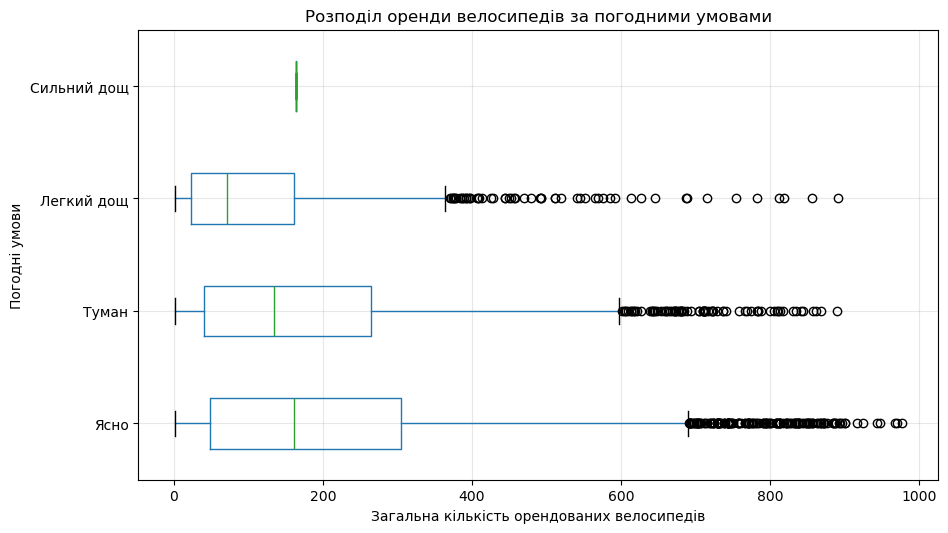

In [15]:
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
df['weather_condition'] = pd.Categorical(df['weather_condition'], categories=weather_order, ordered=True)

df.boxplot(
    column='count',
    by='weather_condition',
    figsize=(10, 6),
    vert=False
)

plt.title('Розподіл оренди велосипедів за погодними умовами')
plt.suptitle('')
plt.xlabel('Загальна кількість орендованих велосипедів')
plt.ylabel('Погодні умови')
plt.grid(True, alpha=0.3);

**Відповіді на питання**:

1. Найбільший розкид у кількості оренди в ясну погоду.
2. Найбільше викидів у ясну погоду, дещо менше в туман та легкий дощ.
3. Медіанне значення оренди найвище в ясну погоду. З огляду на практичну відсутність розподілу оренди велосипедів під час сильного дощу було прийнято рішення не враховувати його медіану, незважаючи на те, що вона візуально близька до медіани, коли ясно (нерепрезентативна вибірка).

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

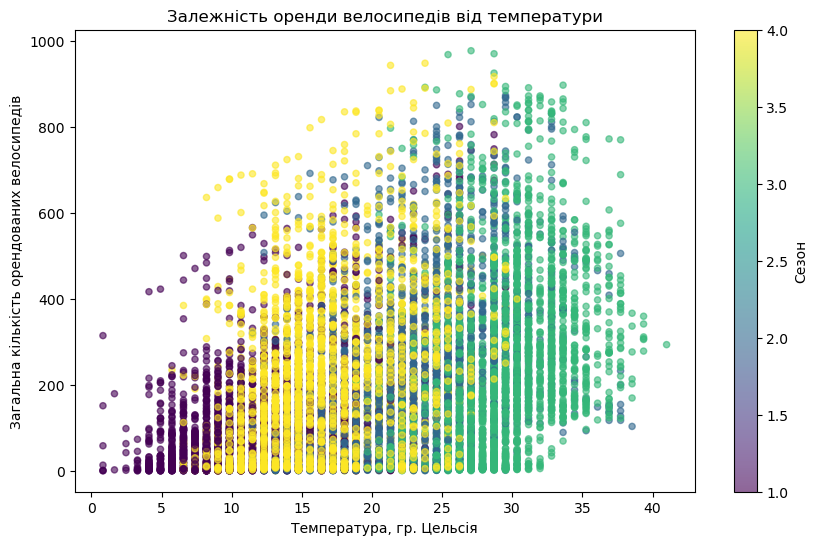

In [16]:
ax = df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    figsize=(10, 6),
    title='Залежність оренди велосипедів від температури',
    xlabel='Температура, гр. Цельсія',
    ylabel='Загальна кількість орендованих велосипедів',
    alpha=0.6,
    colorbar=False
)

cbar = plt.colorbar(ax.collections[0])
cbar.set_label('Сезон')

**Відповідь на питання**:

- Між температурою повітря та кількістю оренди велосипедів спостерігається позитивний зв'язок: зі зростанням температури кількість оренд збільшується.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

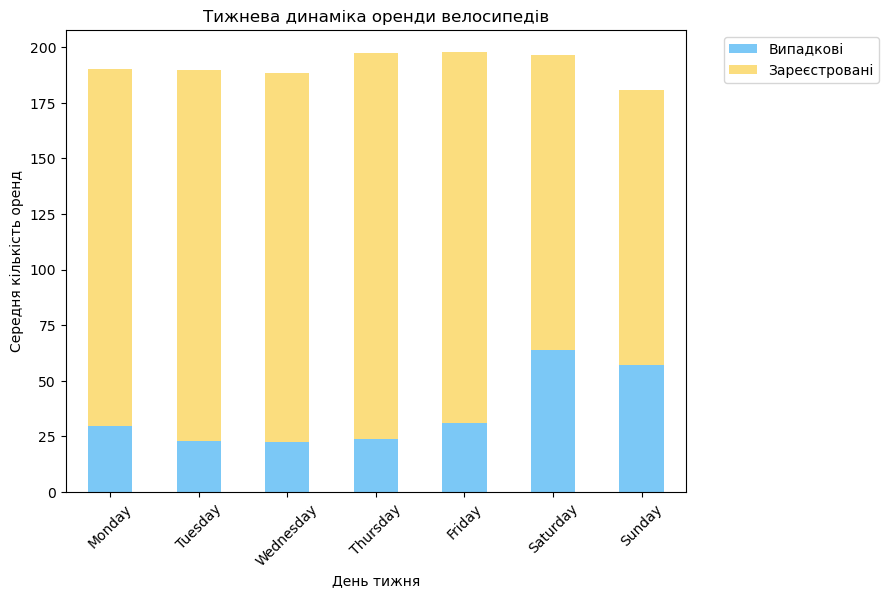

In [17]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['weekday'] = pd.Categorical(df['weekday'], categories=weekday_order, ordered=True)
weekly_avg = df.groupby('weekday', observed=True)[['casual', 'registered']].mean()
colors = ['#7BC8F6', '#FBDD7E']

weekly_avg.plot.bar(
    figsize=(8, 6),
    title='Тижнева динаміка оренди велосипедів',
    xlabel='День тижня',
    ylabel='Середня кількість оренд',
    color=colors,
    stacked=True
)

plt.legend(['Випадкові', 'Зареєстровані'],
           bbox_to_anchor=(1.05, 1),
           loc="best"
)

plt.xticks(rotation=45);

**Відповіді на питання**:

1. В будні дні оренд велосипедів від зареєстрованих користувачів загалом більше, ніж у вихідні.
2. Ймовірно, зареєстровані користувачі — це люди, які використовують велосипед як транспортний засіб, аби дістатися на роботу чи навчання, і саме тому попит у робочі дні вищий, аніж у вихідні. В той час як середня кількість оренд від випадкових користувачів зростає у вихідні дні, що може свідчити про використання велосипеда в якості відпочинку.